
# GNN Pipeline

This notebook assumes the dataset is already cleaned and feature engineered.

It runs four experiments:
1. **GNN without feature-engineered columns**
2. **GNN with feature-engineered columns**
3. **GNN with feature-engineered columns + XGBoost stacker**
4. **GNN with feature-engineered columns + CatBoost stacker**


In [1]:
%pip install -q --no-cache-dir numpy==2.0.2 pandas==2.2.2

%pip install -q --no-cache-dir \
  torch==2.3.1 torchvision==0.18.1 torchaudio==2.3.1 \
  --index-url https://download.pytorch.org/whl/cu121

%pip install -q --no-cache-dir torch-geometric

%pip install -q --no-cache-dir \
  pyg-lib -f https://data.pyg.org/whl/torch-2.3.0+cu121.html

%pip install -q --no-cache-dir xgboost catboost

In [2]:
import numpy as np
import pandas as pd
import torch
import torch_geometric
import xgboost
import catboost

print("numpy:", np.__version__)
print("pandas:", pd.__version__)
print("torch:", torch.__version__)
print("cuda available:", torch.cuda.is_available())
print("pyg:", torch_geometric.__version__)
print("xgboost:", xgboost.__version__)
print("catboost:", catboost.__version__)

numpy: 2.0.2
pandas: 2.2.2
torch: 2.3.1+cu121
cuda available: True
pyg: 2.7.0
xgboost: 3.2.0
catboost: 1.2.10


In [3]:
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import TransformerConv
from torch_geometric.data import Data
from torch_geometric.loader import LinkNeighborLoader
from sklearn.metrics import average_precision_score, roc_auc_score
from torch_geometric.loader import NeighborLoader
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import brier_score_loss
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
base_path = "/content/drive/MyDrive/dataset_cleaned/HI-Medium_Trans.csv"  # change if needed

df = pd.read_csv(base_path)
print("Shape:", df.shape)
df.head()

Shape: (31898218, 21)


,Timestamp,From Bank,Account,To Bank,Account.1,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,...,Log Amount Received,_ts,tx_hour,tx_dow,tx_month,tx_day,tx_date,tx_is_weekend,tx_hour_sin,tx_hour_cos
0,2022/09/01 00:17,20,800104D70,20,800104D70,6794.63,US Dollar,6794.63,US Dollar,Reinvestment,...,8.824035,2022-09-01 00:17:00,0,3,9,1,2022-09-01,0,0.0,1.0
1,2022/09/01 00:02,3196,800107150,3196,800107150,7739.29,US Dollar,7739.29,US Dollar,Reinvestment,...,8.954194,2022-09-01 00:02:00,0,3,9,1,2022-09-01,0,0.0,1.0
2,2022/09/01 00:17,1208,80010E430,1208,80010E430,1880.23,US Dollar,1880.23,US Dollar,Reinvestment,...,7.539681,2022-09-01 00:17:00,0,3,9,1,2022-09-01,0,0.0,1.0
3,2022/09/01 00:03,1208,80010E650,20,80010E6F0,73966883.00,US Dollar,73966883.00,US Dollar,Cheque,...,18.119128,2022-09-01 00:03:00,0,3,9,1,2022-09-01,0,0.0,1.0
4,2022/09/01 00:02,1208,80010E650,20,80010EA30,45868454.00,US Dollar,45868454.00,US Dollar,Cheque,...,17.641288,2022-09-01 00:02:00,0,3,9,1,2022-09-01,0,0.0,1.0


In [6]:
df.columns

Index(['Timestamp', 'From Bank', 'Account', 'To Bank', 'Account.1',
       'Amount Received', 'Receiving Currency', 'Amount Paid',
       'Payment Currency', 'Payment Format', 'Is Laundering',
       'Log Amount Received', '_ts', 'tx_hour', 'tx_dow', 'tx_month', 'tx_day',
       'tx_date', 'tx_is_weekend', 'tx_hour_sin', 'tx_hour_cos'],
      dtype='object')

## Preparation for model

In [7]:
def run_epoch_train(model, loader, opt, crit, device):
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0

    for batch in loader:
        batch = batch.to(device)

        logits = model(batch)
        y = batch.edge_label.to(device)

        loss = crit(logits, y)

        opt.zero_grad()
        loss.backward()
        opt.step()

        bs = y.numel()
        total_loss += float(loss.item()) * bs

        pred = logits.argmax(dim=1)
        correct += int((pred == y).sum().item())
        total += int(bs)

    avg_loss = total_loss / max(total, 1)
    acc = correct / max(total, 1)
    return avg_loss, acc


@torch.no_grad()
def run_epoch_eval(model, loader, crit, device, max_batches=None):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0

    probs_all = []
    ys_all = []

    for i, batch in enumerate(loader):
        if max_batches is not None and i >= max_batches:
            break

        batch = batch.to(device)
        logits = model(batch)
        y = batch.edge_label.to(device)

        loss = crit(logits, y)

        bs = y.numel()
        total_loss += float(loss.item()) * bs

        pred = logits.argmax(dim=1)
        correct += int((pred == y).sum().item())
        total += int(bs)

        prob1 = torch.softmax(logits, dim=1)[:, 1].detach().cpu().numpy()
        probs_all.append(prob1)
        ys_all.append(y.detach().cpu().numpy())

    avg_loss = total_loss / max(total, 1)
    acc = correct / max(total, 1)

    ys = np.concatenate(ys_all) if ys_all else np.array([])
    ps = np.concatenate(probs_all) if probs_all else np.array([])

    if ys.size > 0 and len(np.unique(ys)) > 1:
        pr_auc = average_precision_score(ys, ps)
        roc_auc = roc_auc_score(ys, ps)
    else:
        pr_auc = np.nan
        roc_auc = np.nan

    pos_rate = float(ys.mean()) if ys.size > 0 else np.nan
    return avg_loss, acc, pos_rate, pr_auc, roc_auc

## GNN


In [8]:
required_cols_raw = [
    "From Bank", "Account", "To Bank", "Account.1",
    "Is Laundering"
]
missing_raw = [c for c in required_cols_raw if c not in df.columns]
if missing_raw:
    raise ValueError(f"Missing required columns for original-feature GNN: {missing_raw}")

# Candidate original edge features only
raw_num_candidates = ["Amount Received", "Amount Paid", "Log Amount Received"]
raw_cat_candidates = ["Receiving Currency", "Payment Currency", "Payment Format"]

raw_num_cols = [c for c in raw_num_candidates if c in df.columns]
raw_cat_cols = [c for c in raw_cat_candidates if c in df.columns]

print("Original numeric edge cols:", raw_num_cols)
print("Original categorical edge cols:", raw_cat_cols)

src_key_raw = df["From Bank"].astype(str) + "|" + df["Account"].astype(str)
dst_key_raw = df["To Bank"].astype(str) + "|" + df["Account.1"].astype(str)

all_keys_raw = pd.concat([src_key_raw, dst_key_raw], ignore_index=True)
codes_raw, uniques_raw = pd.factorize(all_keys_raw, sort=False)

E_raw = len(src_key_raw)
src_raw = codes_raw[:E_raw].astype("int64")
dst_raw = codes_raw[E_raw:].astype("int64")
num_nodes_raw = len(uniques_raw)

edge_index_raw = torch.tensor(np.vstack([src_raw, dst_raw]), dtype=torch.long)

raw_num_parts = []
for c in raw_num_cols:
    vals = pd.to_numeric(df[c], errors="coerce").fillna(0).astype(np.float32).to_numpy()
    if vals.size > 0:
        vmax = np.nanmax(np.abs(vals))
        if np.isfinite(vmax) and vmax > 0:
            vals = vals / vmax
    raw_num_parts.append(vals.reshape(-1, 1))

raw_cat_parts = []
for c in raw_cat_cols:
    vals = df[c].astype(str).fillna("MISSING")
    uniq = pd.Index(vals.unique())
    if len(uniq) > 0:
        codes = pd.Categorical(vals, categories=uniq).codes
        onehot = np.eye(len(uniq), dtype=np.float32)[codes]
        raw_cat_parts.append(onehot)

raw_parts = raw_num_parts + raw_cat_parts
if len(raw_parts) == 0:
    edge_attr_raw = np.zeros((len(df), 1), dtype=np.float32)
else:
    edge_attr_raw = np.concatenate(raw_parts, axis=1).astype(np.float32)

y_edge_raw = pd.to_numeric(df["Is Laundering"], errors="coerce").fillna(0).astype("int64").to_numpy()

device_raw = torch.device("cuda" if torch.cuda.is_available() else "cpu")
edge_attr_t_raw = torch.tensor(edge_attr_raw, dtype=torch.float32)
y_edge_t_raw = torch.tensor(y_edge_raw, dtype=torch.long)

data_raw = Data(num_nodes=num_nodes_raw, edge_index=edge_index_raw, edge_attr=edge_attr_t_raw)

edge_ids_raw = torch.arange(edge_index_raw.size(1), dtype=torch.long)
perm_raw = torch.randperm(edge_ids_raw.numel())

n_train_raw = int(0.70 * perm_raw.numel())
n_val_raw = int(0.10 * perm_raw.numel())

train_eids_raw = edge_ids_raw[perm_raw[:n_train_raw]]
val_eids_raw = edge_ids_raw[perm_raw[n_train_raw:n_train_raw + n_val_raw]]
test_eids_raw = edge_ids_raw[perm_raw[n_train_raw + n_val_raw:]]

train_loader_raw = LinkNeighborLoader(
    data_raw,
    edge_label_index=edge_index_raw[:, train_eids_raw],
    edge_label=y_edge_t_raw[train_eids_raw],
    num_neighbors=[15, 10],
    batch_size=4096,
    shuffle=True
)

val_loader_raw = LinkNeighborLoader(
    data_raw,
    edge_label_index=edge_index_raw[:, val_eids_raw],
    edge_label=y_edge_t_raw[val_eids_raw],
    num_neighbors=[15, 10],
    batch_size=4096,
    shuffle=False
)

test_loader_raw = LinkNeighborLoader(
    data_raw,
    edge_label_index=edge_index_raw[:, test_eids_raw],
    edge_label=y_edge_t_raw[test_eids_raw],
    num_neighbors=[15, 10],
    batch_size=4096,
    shuffle=False
)

EDGE_DIM_RAW = data_raw.edge_attr.size(1)
print("num_nodes_raw:", num_nodes_raw, "num_edges_raw:", E_raw)
print("EDGE_DIM_RAW:", EDGE_DIM_RAW)
print("raw split sizes -> train:", len(train_eids_raw), "val:", len(val_eids_raw), "test:", len(test_eids_raw))

Original numeric edge cols: ['Amount Received', 'Amount Paid', 'Log Amount Received']
Original categorical edge cols: ['Receiving Currency', 'Payment Currency', 'Payment Format']
num_nodes_raw: 2077023 num_edges_raw: 31898218
EDGE_DIM_RAW: 40
raw split sizes -> train: 22328752 val: 3189821 test: 6379645


In [9]:
class EdgeAwareGNNRaw(nn.Module):
    def __init__(self, num_nodes, hidden=128, edge_dim=1):
        super().__init__()
        self.emb = nn.Embedding(num_nodes, hidden)
        self.conv1 = TransformerConv(hidden, hidden, edge_dim=edge_dim)
        self.conv2 = TransformerConv(hidden, hidden, edge_dim=edge_dim)
        self.mlp = nn.Sequential(
            nn.Linear(hidden * 4, 256),
            nn.ReLU(),
            nn.Linear(256, 2)
        )

    def forward(self, batch):
        x = self.emb(batch.n_id)
        x = F.relu(self.conv1(x, batch.edge_index, batch.edge_attr))
        x = self.conv2(x, batch.edge_index, batch.edge_attr)

        src_i = batch.edge_label_index[0]
        dst_i = batch.edge_label_index[1]
        hs = x[src_i]
        hd = x[dst_i]
        h = torch.cat([hs, hd, hs * hd, (hs - hd).abs()], dim=-1)
        return self.mlp(h)

model_raw = EdgeAwareGNNRaw(num_nodes=num_nodes_raw, hidden=128, edge_dim=EDGE_DIM_RAW).to(device_raw)
opt_raw = torch.optim.Adam(model_raw.parameters(), lr=2e-3)
crit_raw = nn.CrossEntropyLoss()

EPOCHS_RAW = 3
for epoch in range(1, EPOCHS_RAW + 1):
    tr_loss_raw, tr_acc_raw = run_epoch_train(model_raw, train_loader_raw, opt_raw, crit_raw, device_raw)
    va_loss_raw, va_acc_raw, _, _, _ = run_epoch_eval(model_raw, val_loader_raw, crit_raw, device_raw, max_batches=200)

    print(
        f"[RAW] epoch {epoch} | train loss {tr_loss_raw:.4f} acc {tr_acc_raw:.4f} | "
        f"val loss {va_loss_raw:.4f} acc {va_acc_raw:.4f}"
    )

_, _, val_pos_rate_raw, val_pr_auc_raw, val_roc_auc_raw = run_epoch_eval(
    model_raw, val_loader_raw, crit_raw, device_raw, max_batches=200
)
_, _, test_pos_rate_raw, test_pr_auc_raw, test_roc_auc_raw = run_epoch_eval(
    model_raw, test_loader_raw, crit_raw, device_raw, max_batches=200
)

gnn_raw_metrics = {
    "model": "GNN_original_features",
    "val_pos_rate": val_pos_rate_raw,
    "val_pr_auc": val_pr_auc_raw,
    "val_roc_auc": val_roc_auc_raw,
    "test_pos_rate": test_pos_rate_raw,
    "test_pr_auc": test_pr_auc_raw,
    "test_roc_auc": test_roc_auc_raw,
}

print()
for k, v in gnn_raw_metrics.items():
    if k != "model":
        print(f"{k}: {v:.6f}")

[RAW] epoch 1 | train loss 0.0057 acc 0.9991 | val loss 0.0048 acc 0.9992
[RAW] epoch 2 | train loss 0.0042 acc 0.9992 | val loss 0.0046 acc 0.9992
[RAW] epoch 3 | train loss 0.0036 acc 0.9993 | val loss 0.0047 acc 0.9992

val_pos_rate: 0.001079
val_pr_auc: 0.450184
val_roc_auc: 0.951664
test_pos_rate: 0.001093
test_pr_auc: 0.470255
test_roc_auc: 0.956082


## GNN + Featured Engineering

In [10]:
# Feature-engineered edge features:
# raw_amounts + currencies + payment_format + time_cyclical

required_cols_feat = [
    "From Bank", "Account", "To Bank", "Account.1",
    "Is Laundering",
    "Amount Received", "Amount Paid", "Log Amount Received",
    "Receiving Currency", "Payment Currency", "Payment Format",
    "tx_hour_sin", "tx_hour_cos"
]
missing_feat = [c for c in required_cols_feat if c not in df.columns]
if missing_feat:
    raise ValueError(f"Missing required columns for feature-engineered GNN: {missing_feat}")

feat_num_candidates = [
    "Amount Received",
    "Amount Paid",
    "Log Amount Received",
    "tx_hour_sin",
    "tx_hour_cos"
]
feat_cat_candidates = [
    "Receiving Currency",
    "Payment Currency",
    "Payment Format"
]

feat_num_cols = [c for c in feat_num_candidates if c in df.columns]
feat_cat_cols = [c for c in feat_cat_candidates if c in df.columns]

print("Feature-engineered numeric edge cols:", feat_num_cols)
print("Feature-engineered categorical edge cols:", feat_cat_cols)

feat_num_parts = []
expanded_feat_cols = []

for c in feat_num_cols:
    vals = pd.to_numeric(df[c], errors="coerce").fillna(0).astype(np.float32).to_numpy()
    if vals.size > 0:
        vmax = np.nanmax(np.abs(vals))
        if np.isfinite(vmax) and vmax > 0:
            vals = vals / vmax
    feat_num_parts.append(vals.reshape(-1, 1))
    expanded_feat_cols.append(c)

feat_cat_parts = []
for c in feat_cat_cols:
    vals = df[c].astype(str).fillna("MISSING")
    uniq = pd.Index(vals.unique())
    if len(uniq) > 0:
        codes = pd.Categorical(vals, categories=uniq).codes
        onehot = np.eye(len(uniq), dtype=np.float32)[codes]
        feat_cat_parts.append(onehot)
        expanded_feat_cols.extend([f"{c}__{u}" for u in uniq])

feat_parts = feat_num_parts + feat_cat_parts

if len(feat_parts) == 0:
    edge_attr = np.zeros((len(df), 1), dtype=np.float32)
else:
    edge_attr = np.concatenate(feat_parts, axis=1).astype(np.float32)

y_edge = pd.to_numeric(df["Is Laundering"], errors="coerce").fillna(0).astype("int64").to_numpy()

print()
print("Raw columns:")
print(feat_num_cols + feat_cat_cols)
print()
print("Expanded encoded columns:")
print(expanded_feat_cols)
print()
print("Feature-engineered edge_attr shape:", edge_attr.shape)
print("num_nodes_raw:", num_nodes_raw, "num_edges_raw:", E_raw)

Feature-engineered numeric edge cols: ['Amount Received', 'Amount Paid', 'Log Amount Received', 'tx_hour_sin', 'tx_hour_cos']
Feature-engineered categorical edge cols: ['Receiving Currency', 'Payment Currency', 'Payment Format']

Raw columns:
['Amount Received', 'Amount Paid', 'Log Amount Received', 'tx_hour_sin', 'tx_hour_cos', 'Receiving Currency', 'Payment Currency', 'Payment Format']

Expanded encoded columns:
['Amount Received', 'Amount Paid', 'Log Amount Received', 'tx_hour_sin', 'tx_hour_cos', 'Receiving Currency__US Dollar', 'Receiving Currency__Euro', 'Receiving Currency__UK Pound', 'Receiving Currency__Bitcoin', 'Receiving Currency__Yen', 'Receiving Currency__Yuan', 'Receiving Currency__Canadian Dollar', 'Receiving Currency__Rupee', 'Receiving Currency__Australian Dollar', 'Receiving Currency__Ruble', 'Receiving Currency__Shekel', 'Receiving Currency__Brazil Real', 'Receiving Currency__Mexican Peso', 'Receiving Currency__Swiss Franc', 'Receiving Currency__Saudi Riyal', 'Payme

In [11]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

# Reuse the exact same graph and split as the raw GNN section
edge_index = edge_index_raw
num_nodes = num_nodes_raw
E = E_raw

edge_attr_t = torch.tensor(edge_attr, dtype=torch.float32)
y_edge_t = torch.tensor(y_edge, dtype=torch.long)

data = Data(num_nodes=num_nodes, edge_index=edge_index, edge_attr=edge_attr_t)

train_eids = train_eids_raw
val_eids = val_eids_raw
test_eids = test_eids_raw

train_loader = LinkNeighborLoader(
    data,
    edge_label_index=edge_index[:, train_eids],
    edge_label=y_edge_t[train_eids],
    num_neighbors=[15, 10],
    batch_size=4096,
    shuffle=True
)

val_loader = LinkNeighborLoader(
    data,
    edge_label_index=edge_index[:, val_eids],
    edge_label=y_edge_t[val_eids],
    num_neighbors=[15, 10],
    batch_size=4096,
    shuffle=False
)

test_loader = LinkNeighborLoader(
    data,
    edge_label_index=edge_index[:, test_eids],
    edge_label=y_edge_t[test_eids],
    num_neighbors=[15, 10],
    batch_size=4096,
    shuffle=False
)

print("train batches:", len(train_loader), "val batches:", len(val_loader), "test batches:", len(test_loader))

EDGE_DIM = data.edge_attr.size(1)
print("EDGE_DIM:", EDGE_DIM)
print("feature-engineered split sizes -> train:", len(train_eids), "val:", len(val_eids), "test:", len(test_eids))

device: cuda
train batches: 5452 val batches: 779 test batches: 1558
EDGE_DIM: 42
feature-engineered split sizes -> train: 22328752 val: 3189821 test: 6379645


In [12]:
class EdgeAwareGNN(nn.Module):
    def __init__(self, num_nodes, hidden=128, edge_dim=EDGE_DIM):
        super().__init__()
        self.emb = nn.Embedding(num_nodes, hidden)
        self.conv1 = TransformerConv(hidden, hidden, edge_dim=edge_dim)
        self.conv2 = TransformerConv(hidden, hidden, edge_dim=edge_dim)
        self.mlp = nn.Sequential(
            nn.Linear(hidden * 4, 256),
            nn.ReLU(),
            nn.Linear(256, 2)
        )

    def forward(self, batch):
        x = self.emb(batch.n_id)
        x = F.relu(self.conv1(x, batch.edge_index, batch.edge_attr))
        x = self.conv2(x, batch.edge_index, batch.edge_attr)

        src_i = batch.edge_label_index[0]
        dst_i = batch.edge_label_index[1]
        hs = x[src_i]
        hd = x[dst_i]
        h = torch.cat([hs, hd, hs * hd, (hs - hd).abs()], dim=-1)
        return self.mlp(h)

model = EdgeAwareGNN(num_nodes=num_nodes, hidden=128, edge_dim=EDGE_DIM).to(device)
opt = torch.optim.Adam(model.parameters(), lr=2e-3)
crit = nn.CrossEntropyLoss()

In [13]:
EPOCHS = 3

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = run_epoch_train(model, train_loader, opt, crit, device)
    va_loss, va_acc, _, _, _ = run_epoch_eval(model, val_loader, crit, device, max_batches=200)

    print(
        f"epoch {epoch} | train loss {tr_loss:.4f} acc {tr_acc:.4f} | "
        f"val loss {va_loss:.4f} acc {va_acc:.4f}"
    )

epoch 1 | train loss 0.0056 acc 0.9991 | val loss 0.0046 acc 0.9992
epoch 2 | train loss 0.0042 acc 0.9992 | val loss 0.0045 acc 0.9992
epoch 3 | train loss 0.0036 acc 0.9993 | val loss 0.0046 acc 0.9992


In [14]:
_, _, val_pos_rate, val_pr_auc, val_roc_auc = run_epoch_eval(model, val_loader, crit, device, max_batches=200)
_, _, test_pos_rate, test_pr_auc, test_roc_auc = run_epoch_eval(model, test_loader, crit, device, max_batches=200)

gnn_feat_metrics = {
    "model": "GNN_feature_engineered",
    "val_pos_rate": val_pos_rate,
    "val_pr_auc": val_pr_auc,
    "val_roc_auc": val_roc_auc,
    "test_pos_rate": test_pos_rate,
    "test_pr_auc": test_pr_auc,
    "test_roc_auc": test_roc_auc,
}

print()
for k, v in gnn_feat_metrics.items():
    if k != "model":
        print(f"{k}: {v:.6f}")


val_pos_rate: 0.001079
val_pr_auc: 0.433662
val_roc_auc: 0.943955
test_pos_rate: 0.001093
test_pr_auc: 0.468448
test_roc_auc: 0.944018


## GNN + XGBoost

In [15]:
def encode_batch_xgb(model, batch):
    x = model.emb(batch.n_id)
    x = F.relu(model.conv1(x, batch.edge_index, batch.edge_attr))
    x = model.conv2(x, batch.edge_index, batch.edge_attr)
    return x

hidden_xgb = 128  # must match GNN hidden size
H_xgb = np.zeros((num_nodes, hidden_xgb), dtype=np.float32)

infer_loader_xgb = NeighborLoader(
    data,
    input_nodes=torch.arange(num_nodes),
    num_neighbors=[10, 5],
    batch_size=65536,
    shuffle=False,
    num_workers=2,
    persistent_workers=True
)

model.eval()
with torch.no_grad():
    for batch in infer_loader_xgb:
        batch = batch.to(device)
        z = encode_batch_xgb(model, batch).detach().cpu().numpy()
        H_xgb[batch.n_id.cpu().numpy()] = z

print("Embeddings stored for XGBoost:", H_xgb.shape, "dtype:", H_xgb.dtype)


Embeddings stored for XGBoost: (2077023, 128) dtype: float32


In [16]:
def build_xgb_Xy(edge_ids, edge_index, edge_attr_t, y_edge_t, H):
    if hasattr(edge_ids, "detach"):
        edge_ids_np = edge_ids.detach().cpu().numpy()
    else:
        edge_ids_np = np.asarray(edge_ids)

    src = edge_index[0, edge_ids_np].detach().cpu().numpy()
    dst = edge_index[1, edge_ids_np].detach().cpu().numpy()

    hs = H[src]
    hd = H[dst]
    diff = np.abs(hs - hd)
    had = hs * hd

    eattr = edge_attr_t[edge_ids_np].detach().cpu().numpy()
    X = np.concatenate([hs, hd, diff, had, eattr], axis=1).astype(np.float32)

    y = y_edge_t[edge_ids_np].detach().cpu().numpy()
    return X, y

ts_xgb = pd.to_datetime(df["_ts"], errors="coerce")
if ts_xgb.isna().any():
    ts_xgb = ts_xgb.fillna(ts_xgb.dropna().min())

order_xgb = np.argsort(ts_xgb.values.astype("datetime64[ns]"))
E_xgb = len(order_xgb)

cut_train_xgb = int(0.70 * E_xgb)
cut_val_xgb = int(0.80 * E_xgb)

train_eids_xgb = order_xgb[:cut_train_xgb]
val_eids_xgb = order_xgb[cut_train_xgb:cut_val_xgb]
test_eids_xgb = order_xgb[cut_val_xgb:]

y_np_xgb = y_edge_t.detach().cpu().numpy()
train_pos_xgb = train_eids_xgb[y_np_xgb[train_eids_xgb] == 1]
train_neg_xgb = train_eids_xgb[y_np_xgb[train_eids_xgb] == 0]

neg_mult_xgb = 10
n_pos_xgb = len(train_pos_xgb)
if n_pos_xgb == 0:
    raise ValueError("No positive edges in XGBoost train split.")

n_neg_xgb = min(len(train_neg_xgb), n_pos_xgb * neg_mult_xgb)
rng_xgb = np.random.default_rng(42)
train_neg_sample_xgb = rng_xgb.choice(train_neg_xgb, size=n_neg_xgb, replace=False)

train_sel_xgb = np.concatenate([train_pos_xgb, train_neg_sample_xgb])
rng_xgb.shuffle(train_sel_xgb)

X_train_xgb, y_train_xgb = build_xgb_Xy(train_sel_xgb, edge_index, data.edge_attr, y_edge_t, H_xgb)
X_val_xgb, y_val_xgb = build_xgb_Xy(val_eids_xgb, edge_index, data.edge_attr, y_edge_t, H_xgb)
X_test_xgb, y_test_xgb = build_xgb_Xy(test_eids_xgb, edge_index, data.edge_attr, y_edge_t, H_xgb)

print("X_train_xgb:", X_train_xgb.shape, "X_val_xgb:", X_val_xgb.shape, "X_test_xgb:", X_test_xgb.shape)
print("Train sampled pos rate:", float(y_train_xgb.mean()))
print("Val pos rate:", float(y_val_xgb.mean()))
print("Test pos rate:", float(y_test_xgb.mean()))

X_train_xgb: (231913, 554) X_val_xgb: (3189822, 554) X_test_xgb: (6379644, 554)
Train sampled pos rate: 0.09090909090909091
Val pos rate: 0.001099120891385162
Test pos rate: 0.0016679614097589144


In [17]:
scale_pos_weight_xgb = (len(y_train_xgb) - y_train_xgb.sum()) / max(y_train_xgb.sum(), 1)

xgb = XGBClassifier(
    n_estimators=1200,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="aucpr",
    scale_pos_weight=scale_pos_weight_xgb,
    random_state=42,
    tree_method="hist",
    n_jobs=-1,
)

xgb.fit(
    X_train_xgb, y_train_xgb,
    eval_set=[(X_val_xgb, y_val_xgb)],
    verbose=200
)

p_val_xgb = xgb.predict_proba(X_val_xgb)[:, 1]
p_test_xgb = xgb.predict_proba(X_test_xgb)[:, 1]

gnn_xgb_metrics = {
    "model": "GNN_plus_XGBoost",
    "val_pos_rate": float(y_val_xgb.mean()),
    "val_pr_auc": average_precision_score(y_val_xgb, p_val_xgb),
    "val_roc_auc": roc_auc_score(y_val_xgb, p_val_xgb),
    "test_pos_rate": float(y_test_xgb.mean()),
    "test_pr_auc": average_precision_score(y_test_xgb, p_test_xgb),
    "test_roc_auc": roc_auc_score(y_test_xgb, p_test_xgb),
}

print()
for k, v in gnn_xgb_metrics.items():
    if k != "model":
        print(f"{k}: {v:.6f}")


[0]	validation_0-aucpr:0.05369
[200]	validation_0-aucpr:0.40421
[400]	validation_0-aucpr:0.42972
[600]	validation_0-aucpr:0.43734
[800]	validation_0-aucpr:0.44290
[1000]	validation_0-aucpr:0.44708
[1199]	validation_0-aucpr:0.45048

val_pos_rate: 0.001099
val_pr_auc: 0.450532
val_roc_auc: 0.982602
test_pos_rate: 0.001668
test_pr_auc: 0.558080
test_roc_auc: 0.986604


## GNN + CatBoost

In [18]:
def encode_batch(model, batch):
    # returns node embeddings for the sampled nodes in this batch
    x = model.emb(batch.n_id)
    x = F.relu(model.conv1(x, batch.edge_index, batch.edge_attr))
    x = model.conv2(x, batch.edge_index, batch.edge_attr)
    return x

hidden = 128  # MUST match your model hidden size

# in-memory embeddings: (num_nodes, hidden)
H = np.zeros((num_nodes, hidden), dtype=np.float32)

infer_loader = NeighborLoader(
    data,
    input_nodes=torch.arange(num_nodes),
    num_neighbors=[10, 5],
    batch_size=65536,
    shuffle=False,
    num_workers=2,
    persistent_workers=True
)

model.eval()
with torch.no_grad():
    for batch in infer_loader:
        batch = batch.to(device)
        z = encode_batch(model, batch).detach().cpu().numpy()
        H[batch.n_id.cpu().numpy()] = z

print("Embeddings stored in memory:", H.shape, "dtype:", H.dtype)

Embeddings stored in memory: (2077023, 128) dtype: float32


In [19]:
def build_catboost_Xy(edge_ids, edge_index, edge_attr_t, y_edge_t, H):
    if torch.is_tensor(edge_ids):
        edge_ids_np = edge_ids.detach().cpu().numpy()
    else:
        edge_ids_np = edge_ids

    src = edge_index[0, edge_ids_np].detach().cpu().numpy()
    dst = edge_index[1, edge_ids_np].detach().cpu().numpy()

    hs = H[src]
    hd = H[dst]
    diff = np.abs(hs - hd)
    had = hs * hd

    eattr = edge_attr_t[edge_ids_np].detach().cpu().numpy()
    X = np.concatenate([hs, hd, diff, had, eattr], axis=1)

    y = y_edge_t[edge_ids_np].detach().cpu().numpy()
    return X, y

sample_eids = torch.arange(0, min(10000, edge_index.size(1)))
X_tmp, y_tmp = build_catboost_Xy(sample_eids, edge_index, data.edge_attr, y_edge_t, H)
print("CatBoost X shape:", X_tmp.shape, "y pos rate:", float(y_tmp.mean()))

CatBoost X shape: (10000, 554) y pos rate: 0.0


In [20]:
def build_catboost_Xy(edge_ids, edge_index, edge_attr_t, y_edge_t, H):
    if torch.is_tensor(edge_ids):
        edge_ids_np = edge_ids.detach().cpu().numpy()
    else:
        edge_ids_np = edge_ids

    src = edge_index[0, edge_ids_np].detach().cpu().numpy()
    dst = edge_index[1, edge_ids_np].detach().cpu().numpy()

    hs = H[src]
    hd = H[dst]
    diff = np.abs(hs - hd)
    had = hs * hd

    eattr = edge_attr_t[edge_ids_np].detach().cpu().numpy()
    X = np.concatenate([hs, hd, diff, had, eattr], axis=1)

    y = y_edge_t[edge_ids_np].detach().cpu().numpy()
    return X, y

sample_eids = torch.arange(0, min(10000, edge_index.size(1)))
X_tmp, y_tmp = build_catboost_Xy(sample_eids, edge_index, data.edge_attr, y_edge_t, H)
print("CatBoost X shape:", X_tmp.shape, "y pos rate:", float(y_tmp.mean()))

CatBoost X shape: (10000, 554) y pos rate: 0.0


In [21]:
def build_catboost_Xy(edge_ids, edge_index, edge_attr_t, y_edge_t, H):
    if hasattr(edge_ids, "detach"):
        edge_ids_np = edge_ids.detach().cpu().numpy()
    else:
        edge_ids_np = np.asarray(edge_ids)

    src = edge_index[0, edge_ids_np].detach().cpu().numpy()
    dst = edge_index[1, edge_ids_np].detach().cpu().numpy()

    hs = H[src]
    hd = H[dst]
    diff = np.abs(hs - hd)
    had = hs * hd

    eattr = edge_attr_t[edge_ids_np].detach().cpu().numpy()
    X = np.concatenate([hs, hd, diff, had, eattr], axis=1)

    y = y_edge_t[edge_ids_np].detach().cpu().numpy()
    return X, y

In [22]:
ts = pd.to_datetime(df["_ts"], errors="coerce")
if ts.isna().any():
    ts = ts.fillna(ts.dropna().min())

# sort edges by timestamp
order = np.argsort(ts.values.astype("datetime64[ns]"))
E = len(order)

cut_train = int(0.70 * E)
cut_val = int(0.80 * E)

train_eids = order[:cut_train]
val_eids = order[cut_train:cut_val]
test_eids = order[cut_val:]

y_np = y_edge_t.detach().cpu().numpy()
train_pos = train_eids[y_np[train_eids] == 1]
train_neg = train_eids[y_np[train_eids] == 0]

print("Train pos rate:", float(y_np[train_eids].mean()))
print("Val pos rate:", float(y_np[val_eids].mean()))
print("Test pos rate:", float(y_np[test_eids].mean()))
print("Train edges:", len(train_eids), "Val edges:", len(val_eids), "Test edges:", len(test_eids))


Train pos rate: 0.0009442086149731969
Val pos rate: 0.001099120891385162
Test pos rate: 0.0016679614097589144
Train edges: 22328752 Val edges: 3189822 Test edges: 6379644


In [23]:
neg_mult = 10
n_pos = len(train_pos)

if n_pos == 0:
    raise ValueError("No positive edges in train split. Something is wrong with labels or split.")

n_neg = min(len(train_neg), n_pos * neg_mult)

rng = np.random.default_rng(42)
train_neg_sample = rng.choice(train_neg, size=n_neg, replace=False)

train_sel = np.concatenate([train_pos, train_neg_sample])
rng.shuffle(train_sel)

print("CatBoost train_sel:", len(train_sel), "pos:", n_pos, "neg:", n_neg, "pos_rate:", n_pos / len(train_sel))


CatBoost train_sel: 231913 pos: 21083 neg: 210830 pos_rate: 0.09090909090909091


In [24]:
X_train, y_train = build_catboost_Xy(train_sel, edge_index, data.edge_attr, y_edge_t, H)
X_val, y_val = build_catboost_Xy(val_eids, edge_index, data.edge_attr, y_edge_t, H)
X_test, y_test = build_catboost_Xy(test_eids, edge_index, data.edge_attr, y_edge_t, H)

print("X_train:", X_train.shape, "X_val:", X_val.shape, "X_test:", X_test.shape)
print("Pos rates -> train:", y_train.mean(), "val:", y_val.mean(), "test:", y_test.mean())


X_train: (231913, 554) X_val: (3189822, 554) X_test: (6379644, 554)
Pos rates -> train: 0.09090909090909091 val: 0.001099120891385162 test: 0.0016679614097589144


In [25]:
cb = CatBoostClassifier(
    iterations=2000,
    learning_rate=0.05,
    depth=8,
    loss_function="Logloss",
    eval_metric="AUC",
    random_seed=42,
    verbose=200,
    task_type="GPU" if False else "CPU"
)

cb.fit(
    X_train, y_train,
    eval_set=(X_val, y_val),
    use_best_model=True
)

0:	test: 0.9556701	best: 0.9556701 (0)	total: 424ms	remaining: 14m 7s
200:	test: 0.9814393	best: 0.9814393 (200)	total: 1m 7s	remaining: 10m 7s
400:	test: 0.9829512	best: 0.9829512 (400)	total: 2m 13s	remaining: 8m 53s
600:	test: 0.9834308	best: 0.9834314 (599)	total: 3m 18s	remaining: 7m 42s
800:	test: 0.9836037	best: 0.9836352 (729)	total: 4m 22s	remaining: 6m 33s
1000:	test: 0.9837855	best: 0.9837855 (1000)	total: 5m 27s	remaining: 5m 26s
1200:	test: 0.9839066	best: 0.9839139 (1198)	total: 6m 31s	remaining: 4m 20s
1400:	test: 0.9838039	best: 0.9839139 (1198)	total: 7m 36s	remaining: 3m 15s
1600:	test: 0.9838080	best: 0.9839139 (1198)	total: 8m 40s	remaining: 2m 9s
1800:	test: 0.9838283	best: 0.9839139 (1198)	total: 9m 45s	remaining: 1m 4s
1999:	test: 0.9838572	best: 0.9839139 (1198)	total: 10m 49s	remaining: 0us

bestTest = 0.9839138861
bestIteration = 1198

Shrink model to first 1199 iterations.


CatBoostClassifier(depth=8, eval_metric='AUC', iterations=2000, learning_rate=0.05, loss_function='Logloss', random_seed=42, task_type='CPU', verbose=200)

In [26]:
p_val_raw = cb.predict_proba(X_val)[:, 1]
p_test_raw = cb.predict_proba(X_test)[:, 1]

cat_metrics = {
    "model": "GNN_plus_CatBoost",
    "val_pos_rate": float(y_val.mean()),
    "val_pr_auc": average_precision_score(y_val, p_val_raw),
    "val_roc_auc": roc_auc_score(y_val, p_val_raw),
    "test_pos_rate": float(y_test.mean()),
    "test_pr_auc": average_precision_score(y_test, p_test_raw),
    "test_roc_auc": roc_auc_score(y_test, p_test_raw),
}

print()
for k, v in cat_metrics.items():
    if k != "model":
        print(f"{k}: {v:.6f}")


val_pos_rate: 0.001099
val_pr_auc: 0.484954
val_roc_auc: 0.983914
test_pos_rate: 0.001668
test_pr_auc: 0.591287
test_roc_auc: 0.987767


Confusion Matrix (Test Set)
[[6300868   68135]
 [   1994    8647]]


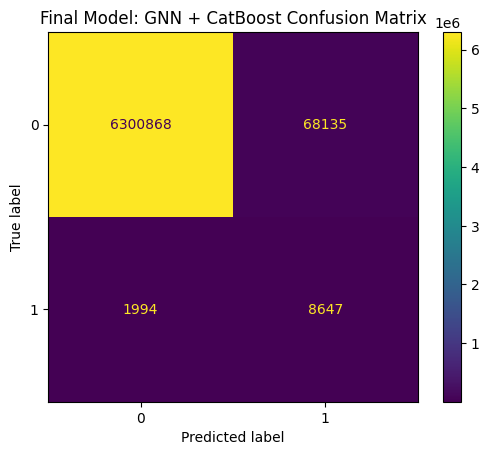


Precision: 0.11261754056940429
Recall: 0.8126115966544498
F1 Score: 0.1978197957059355


In [27]:
threshold = 0.5
y_pred_test = (p_test_raw >= threshold).astype(int)
cm = confusion_matrix(y_test, y_pred_test)

print("Confusion Matrix (Test Set)")
print(cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(values_format="d")
plt.title("Final Model: GNN + CatBoost Confusion Matrix")
plt.show()

precision = precision_score(y_test, y_pred_test)
recall = recall_score(y_test, y_pred_test)
f1 = f1_score(y_test, y_pred_test)

print()
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

In [28]:

comparison_table = pd.DataFrame([
    {
        "model": gnn_raw_metrics["model"],
        "val_roc_auc": gnn_raw_metrics["val_roc_auc"],
        "val_pr_auc": gnn_raw_metrics["val_pr_auc"],
        "test_roc_auc": gnn_raw_metrics["test_roc_auc"],
        "test_pr_auc": gnn_raw_metrics["test_pr_auc"],
    },
    {
        "model": gnn_feat_metrics["model"],
        "val_roc_auc": gnn_feat_metrics["val_roc_auc"],
        "val_pr_auc": gnn_feat_metrics["val_pr_auc"],
        "test_roc_auc": gnn_feat_metrics["test_roc_auc"],
        "test_pr_auc": gnn_feat_metrics["test_pr_auc"],
    },
    {
        "model": gnn_xgb_metrics["model"],
        "val_roc_auc": gnn_xgb_metrics["val_roc_auc"],
        "val_pr_auc": gnn_xgb_metrics["val_pr_auc"],
        "test_roc_auc": gnn_xgb_metrics["test_roc_auc"],
        "test_pr_auc": gnn_xgb_metrics["test_pr_auc"],
    },
    {
        "model": cat_metrics["model"],
        "val_roc_auc": cat_metrics["val_roc_auc"],
        "val_pr_auc": cat_metrics["val_pr_auc"],
        "test_roc_auc": cat_metrics["test_roc_auc"],
        "test_pr_auc": cat_metrics["test_pr_auc"],
    },
])

comparison_table


,model,val_roc_auc,val_pr_auc,test_roc_auc,test_pr_auc
0,GNN_original_features,0.951664,0.450184,0.956082,0.470255
1,GNN_feature_engineered,0.943955,0.433662,0.944018,0.468448
2,GNN_plus_XGBoost,0.982602,0.450532,0.986604,0.558080
3,GNN_plus_CatBoost,0.983914,0.484954,0.987767,0.591287


# Model Performance

In [29]:
iso = IsotonicRegression(out_of_bounds="clip")

iso.fit(p_val_raw, y_val)

p_val_cal = iso.transform(p_val_raw)
p_test_cal = iso.transform(p_test_raw)

print("Calibration complete")

Calibration complete


In [30]:
p_test_cal

array([0.        , 0.        , 0.        , ..., 0.00227309, 0.00227309,
       0.7241379 ], dtype=float32)

In [31]:
print("Raw Brier:", brier_score_loss(y_test, p_test_raw))
print("Calibrated Brier:", brier_score_loss(y_test, p_test_cal))

Raw Brier: 0.009510250285575358
Calibrated Brier: 0.0012172373929718156


In [32]:
results = pd.DataFrame({
    "edge_id": test_eids,
    "timestamp": ts.iloc[test_eids].values,
    "label": y_test,
    "score_raw": p_test_raw,
    "risk_prob": p_test_cal
})

results = results.sort_values("risk_prob", ascending=False)

results.head(10)

,edge_id,timestamp,label,score_raw,risk_prob
6373308,23054278,2022-09-17 09:26:00,1,0.999914,0.974874
6372792,27464386,2022-09-17 02:48:00,1,0.999928,0.974874
6373413,22999661,2022-09-17 10:30:00,1,0.999879,0.974874
6379420,27777865,2022-09-24 15:09:00,1,0.999884,0.974874
6379545,26858431,2022-09-25 18:36:00,1,0.999965,0.974874
1003063,21055497,2022-09-14 18:38:00,1,0.999918,0.974874
2525383,19580928,2022-09-15 13:23:00,1,0.999880,0.974874
6375701,24046605,2022-09-18 14:32:00,1,0.999889,0.974874
2538907,24656825,2022-09-15 13:34:00,1,0.999881,0.974874
6375692,23797435,2022-09-18 14:23:00,1,0.999888,0.974874


In [33]:
results["date"] = pd.to_datetime(results["timestamp"]).dt.date

alerts_per_day = results.groupby("date").size().reset_index(name="alerts")

alerts_per_day.head()

,date,alerts
0,2022-09-14,1420377
1,2022-09-15,1930417
2,2022-09-16,3021863
3,2022-09-17,2020
4,2022-09-18,1591


In [34]:
top500 = results.sort_values("risk_prob", ascending=False).head(500)

true_cases = top500["label"].sum()

precision_at_500 = true_cases / 500

print("True laundering cases in top 500:", true_cases)
print("Precision@500:", precision_at_500)

True laundering cases in top 500: 493
Precision@500: 0.986


In [35]:
total_laundering = results["label"].sum()

recall_at_500 = true_cases / total_laundering

print("Total laundering transactions:", total_laundering)
print("Recall@500:", recall_at_500)

Total laundering transactions: 10641
Recall@500: 0.04633023212104125
